In [94]:
import h5py
import torch
import random
from functools import partial
from torch.utils.data import DataLoader
from torch.utils.data.distributed import DistributedSampler
import numpy as np
from pathlib import Path
from torch.utils.data import Dataset

class H5Dataset(Dataset):
    def __init__(
        self,
        data_dir: str,
        window_size: int,
        stride: int = 1,
        shuffle_windows: bool = True,
        shard_glob: str = "*.h5",
        img_key='images',
        action_key=None,
        state_key=None,
        reward_key=None,
        is_done_key=None,
        bgr_to_rgb: bool = False,
        overlapping = True,
        pushT_backward_compatibility = False, # A temporary hack to support the old pushT dataset which had a non-standard layout and naming convention. Ignored if the dataset doesn't match that layout.
    ):
        self.pushT_backward_compatibility = pushT_backward_compatibility
        self.data_dir = Path(data_dir)
        self.window_size = window_size
        self.stride = stride
        self.shuffle_windows = shuffle_windows
        self.img_key = img_key
        self.action_key = action_key
        self.state_key = state_key
        self.reward_key = reward_key
        self.is_done_key = is_done_key
        self.bgr_to_rgb = bgr_to_rgb
        self.keys = [k for k in (img_key, action_key, state_key, reward_key, is_done_key) if k is not None]
        if img_key is not None:
            len_key = img_key
        elif action_key is not None:
            len_key = action_key
        
        # Auto-discover shards (sorted by filename for determinism)
        self.shard_files = sorted(self.data_dir.glob(shard_glob))
        if not self.shard_files:
            raise FileNotFoundError(
                f"No shards matched {shard_glob!r} under {self.data_dir}"
            )
        self.num_shards = len(self.shard_files)
        self.episodes = []
        for shard_idx, shard_file in enumerate(self.shard_files):
            with h5py.File(shard_file, 'r') as f:
                if img_key is not None:
                    assert img_key in f.keys(), f"Shard {shard_file} is missing required key {img_key}. Available keys: {list(f.keys())}"
                if action_key is not None:
                    assert action_key in f.keys(), f"Shard {shard_file} is missing required key {action_key}. Available keys: {list(f.keys())}"
                if state_key is not None:
                    assert state_key in f.keys(), f"Shard {shard_file} is missing required key {state_key}. Available keys: {list(f.keys())}"
                if reward_key is not None:
                    assert reward_key in f.keys(), f"Shard {shard_file} is missing required key {reward_key}. Available keys: {list(f.keys())}"
                if pushT_backward_compatibility:
                    ep_len = f[len_key].shape[1] 
                else:
                    ep_len = f[len_key].shape[0]   
                self.episodes.append((shard_idx, ep_len))
        self.windows = []  
        for shard_idx, length in self.episodes:
            if overlapping:
                starts = torch.arange(0, length - window_size + 1, 1)
                ends = starts + window_size
                idx = torch.ones(len(starts), dtype=torch.long) * shard_idx
                w = torch.stack((idx, starts, ends), dim=1)
                self.windows.append(w)
            else:
                starts = torch.arange(0, length - window_size + 1, stride)
                ends = starts + window_size
                idx = torch.ones(len(starts), dtype=torch.long) * shard_idx
                w = torch.stack((idx, starts, ends), dim=1)
                self.windows.append(w)
        self.windows = torch.vstack(self.windows).tolist() 
        if self.shuffle_windows:
            random.shuffle(self.windows)

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        shard_idx, start, end= self.windows[idx]
        out = {}
        with h5py.File(self.shard_files[shard_idx], 'r') as f:
            for k in self.keys:
                if self.pushT_backward_compatibility:
                    arr = f[k][0, start:end]
                else:
                    arr = f[k][start:end]
                if k==self.img_key:
                    if self.bgr_to_rgb and arr.ndim >= 1 and arr.shape[-1] == 3:
                        arr = arr[..., ::-1]
                    t = torch.from_numpy(np.ascontiguousarray(arr)).float() / 255.0
                    if t.ndim == 4:  # (T, H, W, C) → (T, C, H, W)
                        t = t.permute(0, 3, 1, 2).contiguous()
                else:
                    t = torch.from_numpy(np.ascontiguousarray(arr))
                if self.pushT_backward_compatibility and k == self.action_key:
                    out[k] = t[:, :2]
                else:
                    out[k] = t
        return out
    

In [95]:
DATA_DIR = '/home/mim-server/robot/GR00T-WholeBodyControl/wm_h5_segmented_small'
# DATA_DIR = '/home/mim-server/datasets/pushT/sharded'
DATA_DIR = "/media/mim-server/5a9b3378-c509-41de-b07f-544b25e6a481/soar_data_sharded"
WINDOW_SIZE = 32
STRIDE = 1

dataset = H5Dataset(
    data_dir=DATA_DIR,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    shuffle_windows=True,
    img_key='images',
    action_key='actions',
    bgr_to_rgb=False, 
    overlapping=False, 
    pushT_backward_compatibility=True
)

print(f'num shards:   {dataset.num_shards}')
# print(f'num episodes: {len(dataset.episodes)}')
print(f'num windows:  {len(dataset)}')
print(f'keys:         {dataset.keys}')

num shards:   62
num windows:  11431
keys:         ['images', 'actions']


In [92]:
dataset[0]['images'].shape

torch.Size([32, 3, 256, 256])

In [93]:
import torch
import mediapy as media
pick_idx = torch.randint(len(dataset), (1,)).item()
sample = dataset[pick_idx]
video = sample['images'].permute(0, 2, 3, 1).numpy()  # (T, H, W, C), float in [0,1]
media.show_video(video, fps=20, title=f'window {pick_idx}')

window 1350 This browser does not support the video tag.


## Plot actions (`commands`) and proprioception

Both are `(T, D)` float tensors — overlaid as line plots per dim.

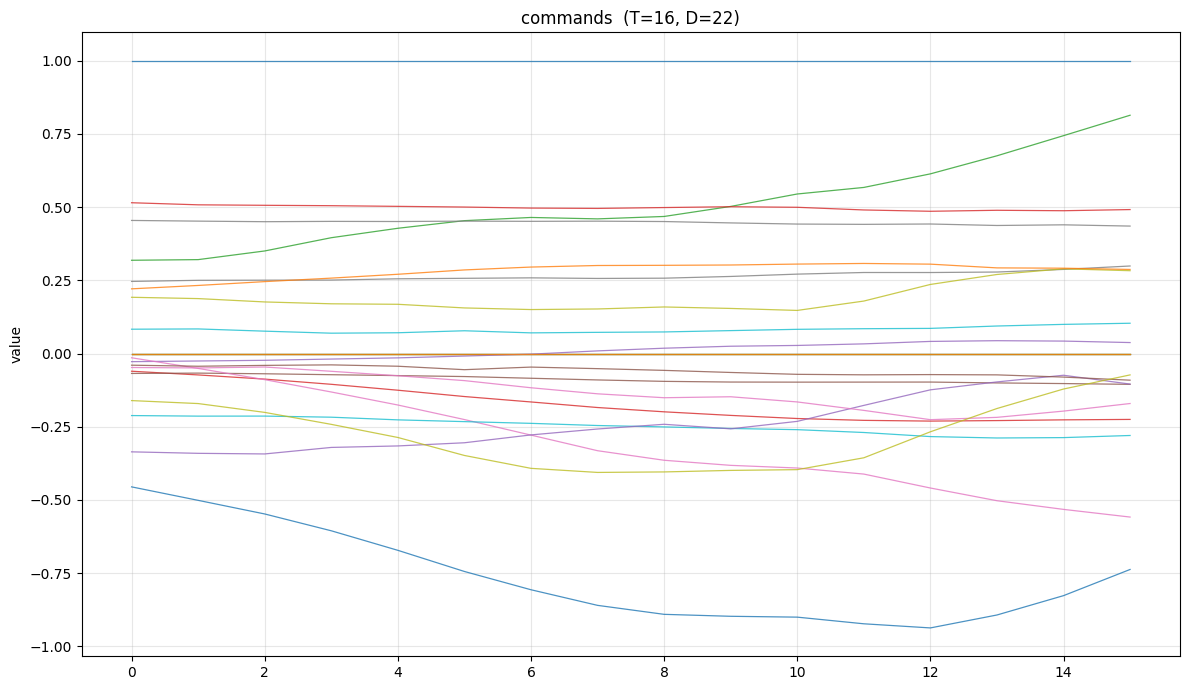

In [66]:
import matplotlib.pyplot as plt
actions = sample['commands'].numpy()   # (T, 22)
t = np.arange(actions.shape[0])

fig, axes = plt.subplots(1, 1, figsize=(12, 7), sharex=True)

for d in range(actions.shape[1]):
    axes.plot(t, actions[:, d], linewidth=0.9, alpha=0.8)
axes.set_title(f'commands  (T={actions.shape[0]}, D={actions.shape[1]})')
axes.set_ylabel('value')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()